In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        continue;

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Cell 1: Imports & Environment Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2026-05-14 17:04:18.311874: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778778258.523521      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778778258.588340      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778778259.090320      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778778259.090372      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778778259.090375      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### Below

In the next cell, I define the dataset path and inspect the folder structure. The code walks through the Kaggle input directory and prints the training and testing folders, including the class folders for **glioma**, **meningioma**, **notumor**, and **pituitary**.

This step is important because Keras image generators use folder names as class labels. Before I train a model, I need to confirm that the expected folders exist and that each class contains images. This also helps me check whether the dataset is balanced across the four categories.

In [3]:
# Cell 2: Dataset Path & Class Discovery
# Kaggle Brain Tumor MRI dataset path
DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

# Walk through directories to find train/test structure
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')

TRAIN_DIR = os.path.join(DATASET_PATH, "Training")
TEST_DIR  = os.path.join(DATASET_PATH, "Testing")

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")

# Count images per class
print("\nTraining set distribution:")
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"  {cls}: {n} images")

print("\nTest set distribution:")
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(TEST_DIR, cls)))
    print(f"  {cls}: {n} images")

brain-tumor-mri-dataset/
  Training/
    pituitary/
    notumor/
    meningioma/
    glioma/
  Testing/
    pituitary/
    notumor/
    meningioma/
    glioma/

Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']

Training set distribution:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

Test set distribution:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images


### Output --

In this output, I can observe the dataset directory structure. The main folder contains **Training** and **Testing** folders, and each of these contains four class folders: **pituitary**, **notumor**, **meningioma**, and **glioma**. The printed class list is ordered as **glioma**, **meningioma**, **notumor**, and **pituitary**.

The training set distribution shows **1400 images** for each class, and the test set distribution shows **400 images** for each class. This means the dataset contains **5600 training images** and **1600 testing images**, with a balanced class structure. Since each class has the same number of images, the model is not being biased by one class having more examples than another.

I conclude that the dataset is suitable for multiclass classification. The balanced folder structure also makes later metrics such as accuracy, precision, recall, and F1 score easier to interpret fairly.

### Below

In the next cell, I set the global hyperparameters for the ResNet50 transfer learning experiment. These include **IMG_SIZE**, **BATCH_SIZE**, **EPOCHS_FE**, **EPOCHS_FT**, **LR_FE**, and **LR_FT**. I also define the number of classes and confirm the class names used throughout the notebook.

This setup is necessary because transfer learning is trained in two stages. The first stage is **feature extraction**, where the pretrained ResNet50 base is frozen and only the new classification head learns. The second stage is **fine tuning**, where selected upper layers of ResNet50 are unfrozen and updated using a smaller learning rate.

In [4]:
# Cell 3: Global Hyperparameters
IMG_SIZE    = (224, 224)   # ResNet50 expected input
BATCH_SIZE  = 32
EPOCHS_FE   = 10           # Feature Extraction phase
EPOCHS_FT   = 10           # Fine-Tuning phase
LR_FE       = 1e-3         # Learning rate for feature extraction
LR_FT       = 1e-5         # Lower LR for fine-tuning (avoid catastrophic forgetting)
SEED        = 42

print("Configuration:")
print(f"  Image Size   : {IMG_SIZE}")
print(f"  Batch Size   : {BATCH_SIZE}")
print(f"  Num Classes  : {NUM_CLASSES}")
print(f"  FE Epochs    : {EPOCHS_FE}")
print(f"  FT Epochs    : {EPOCHS_FT}")
print(f"  FE LR        : {LR_FE}")
print(f"  FT LR        : {LR_FT}")

Configuration:
  Image Size   : (224, 224)
  Batch Size   : 32
  Num Classes  : 4
  FE Epochs    : 10
  FT Epochs    : 10
  FE LR        : 0.001
  FT LR        : 1e-05


### Output --

In this output, I can observe the main configuration for the ResNet50 experiment. The image size is **224 by 224**, the batch size is **32**, the number of classes is **4**, and the training is divided into **10 feature extraction epochs** and **10 fine tuning epochs**. The learning rate is **0.001** for feature extraction and **0.00001** for fine tuning.

These values are important because they define how the model will train. ResNet50 expects images in the 224 by 224 format, so all MRI scans are resized accordingly. The two learning rates also reflect the transfer learning strategy. A larger learning rate is used when training only the new classification head, while a smaller learning rate is used when updating pretrained ResNet layers.

I conclude that the experiment is organized clearly into two controlled phases. This structure reduces the risk of damaging pretrained weights too early and gives the model a better chance to adapt to MRI images.

### Below

In the next cell, I create the image data generators for training, validation, and testing. The training generator applies ResNet50 preprocessing and data augmentation, while the validation and test generators apply only the required preprocessing.

This cell prepares the data pipeline for transfer learning. Augmentation such as rotation, shifting, shearing, zooming, and horizontal flipping helps the model see varied versions of the training images. The validation split separates part of the training data for monitoring model performance, while the test generator remains separate for final evaluation.

In [5]:
# Cell 4: Data Augmentation & Generators
# ResNet50 expects inputs preprocessed with its specific function
train_datagen = ImageDataGenerator(
    preprocessing_function=keras.applications.resnet50.preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15        # 15% of training set → validation
)

test_datagen = ImageDataGenerator(
    preprocessing_function=keras.applications.resnet50.preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTrain batches : {len(train_gen)}")
print(f"Val batches   : {len(val_gen)}")
print(f"Test batches  : {len(test_gen)}")
print(f"\nClass indices : {train_gen.class_indices}")

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Train batches : 149
Val batches   : 27
Test batches  : 50

Class indices : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


### Output --

In this output, I can observe that the image generators successfully found **4760 training images**, **840 validation images**, and **1600 testing images**, all belonging to **4 classes**. The output also reports **149 training batches**, **27 validation batches**, and **50 test batches**. The class index mapping is **glioma: 0**, **meningioma: 1**, **notumor: 2**, and **pituitary: 3**.

This result tells me that the validation split has been created from the original training folder. Since the full training folder contains 5600 images, the generator uses part of it for training and part for validation. The test generator remains separate, which is important because final testing must be done on unseen data.

I conclude that the data pipeline is working correctly. The model can now receive batches of preprocessed MRI images and their labels, while the class index mapping tells me exactly how numerical predictions correspond to class names.

### Below

In the next cell, I display sample MRI images from each class. The code loads one example image from each class folder and shows the images in a grid using matplotlib.

This visual inspection step is important because image classification should not be treated only as numbers. By looking at actual glioma, meningioma, notumor, and pituitary scans, I can confirm that the dataset has meaningful visual differences and that the folder labels appear to match the images.

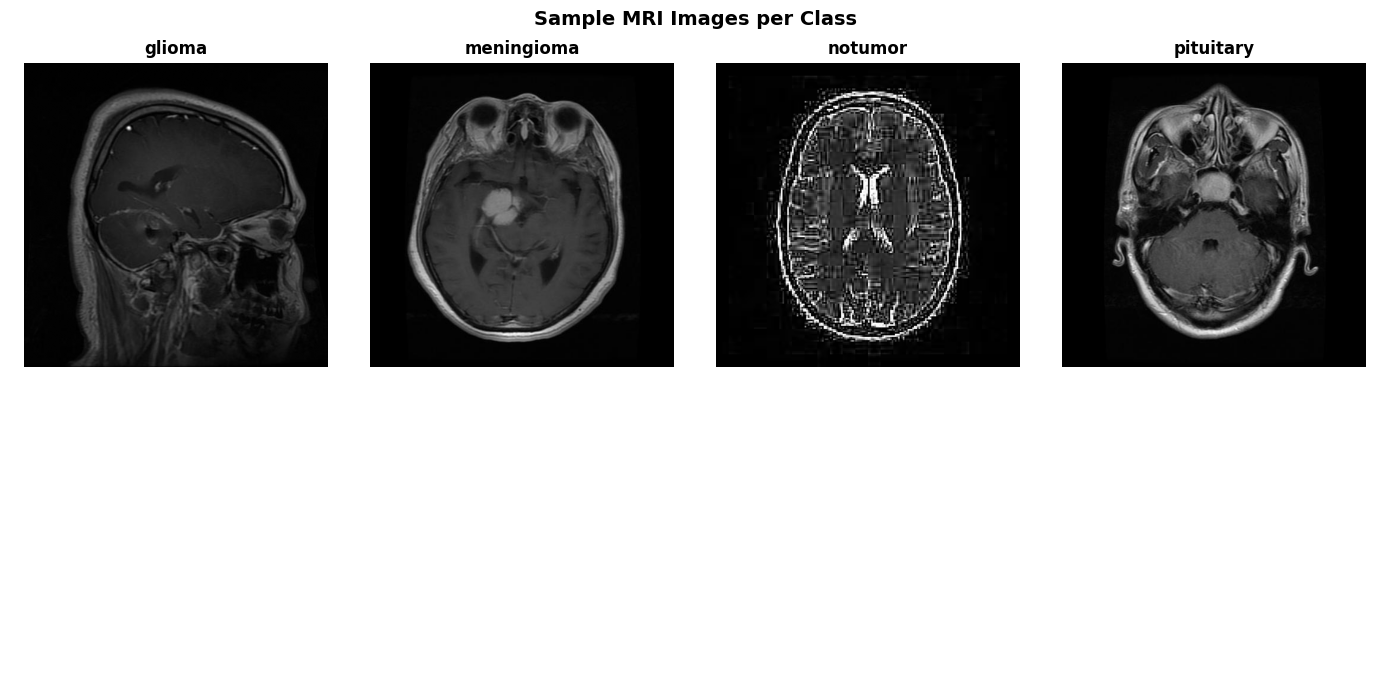

In [6]:
# Cell 5: Visualise Sample Images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_dir)[0]
    img_path = os.path.join(cls_dir, img_file)
    img = plt.imread(img_path)
    axes[i].imshow(img, cmap='gray' if img.ndim == 2 else None)
    axes[i].set_title(cls, fontsize=12, fontweight='bold')
    axes[i].axis('off')

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Sample MRI Images per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

### Output --

In this visualization, I can observe sample MRI images from the four classes: **glioma**, **meningioma**, **notumor**, and **pituitary**. Each displayed image represents one example from the dataset, allowing me to inspect the visual appearance of the categories before training.

This output is useful because it confirms that the images are loaded correctly and that the classes contain real MRI scans. The tumor classes show different brain patterns and possible abnormal regions, while the **notumor** class represents images without a visible tumor label. Some images may still look similar to the human eye, which explains why a deep learning model is useful for learning more detailed image features.

I conclude that the dataset is visually appropriate for CNN based classification. This sample image grid supports the next modelling step because it shows that ResNet50 will be trained on meaningful image data rather than incorrectly loaded files.

### Below

In the next cell, I load the pretrained **ResNet50** model with ImageNet weights and remove its original classification head. Then I add a new custom classification head for the four brain tumor MRI classes.

This is the main transfer learning setup. The ResNet50 base is frozen first, so its pretrained convolutional features are reused without being changed. The new head contains **GlobalAveragePooling2D**, dense layers, dropout, and a final softmax layer. This allows the model to adapt pretrained visual features to the medical MRI classification task.

In [7]:
# Cell 6: Load & Adapt ResNet50
# ── 2.6.1: Load pre-trained ResNet50, exclude top (FC) layers ──
base_model = ResNet50(
    weights='imagenet',
    include_top=False,              # Remove ImageNet 1000-class head
    input_shape=(*IMG_SIZE, 3)
)

print(f"ResNet50 base layers: {len(base_model.layers)}")
print(f"Base model output shape: {base_model.output_shape}")

# ── 2.6.1 / 2.6.2: Freeze entire base for Feature Extraction phase ──
base_model.trainable = False

frozen = sum(1 for l in base_model.layers if not l.trainable)
print(f"Frozen layers: {frozen}")

# ── Add new classification head for NUM_CLASSES ──
inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)          # training=False keeps BN frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)  # Match dataset classes

model = keras.Model(inputs, outputs)
model.summary()

I0000 00:00:1778778320.292061      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778778320.298226      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 base layers: 175
Base model output shape: (None, 7, 7, 2048)
Frozen layers: 175


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,153,860 (92.14 MB)

 Trainable params: 562,052 (2.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

### Output --

In this output, I can observe that the pretrained ResNet50 weights are downloaded and loaded successfully. The output states that the **ResNet50 base has 175 layers**, its output shape is **(None, 7, 7, 2048)**, and all **175 base layers are frozen** during the first training stage.

The model summary shows that the full transfer learning model has **24,153,860 total parameters**. Only **562,052 parameters** are trainable at first, while **23,591,808 parameters** are non trainable. This confirms that the ResNet50 backbone is being used as a fixed feature extractor, while the new classification head learns the brain tumor task.

I conclude that the transfer learning architecture is correctly prepared. The base model extracts high level visual features from MRI images, and the custom head converts those features into four class probabilities using the final **softmax** layer.

### Below

In the next cell, I train the model in the first phase called **feature extraction**. During this stage, the ResNet50 base remains frozen and only the newly added classification head is trained.

This approach is useful because the pretrained model already contains general visual knowledge from ImageNet. By training only the new head first, I allow the classifier to learn the MRI classes without immediately changing the pretrained convolutional layers. The callbacks monitor validation loss, reduce learning rate when progress slows, and restore the best weights.

In [8]:
# Cell 7: Feature Extraction Training (frozen base)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fe = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_fe_model.keras', save_best_only=True, verbose=0)
]

print("=" * 50)
print("PHASE 1: Feature Extraction")
print("=" * 50)

start_fe = time.time()

history_fe = model.fit(
    train_gen,
    epochs=EPOCHS_FE,
    validation_data=val_gen,
    callbacks=callbacks_fe,
    verbose=1
)

end_fe = time.time()
fe_training_time = end_fe - start_fe

print(f"\n Feature Extraction Training Time: {fe_training_time:.2f}s "
      f"({fe_training_time/60:.2f} min)")
print(f"   Best Val Accuracy: {max(history_fe.history['val_accuracy']):.4f}")

PHASE 1: Feature Extraction
Epoch 1/10


I0000 00:00:1778778333.160693     153 service.cc:152] XLA service 0x7ae72c051570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778778333.160730     153 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778778333.160734     153 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778778335.268007     153 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/149 ━━━━━━━━━━━━━━━━━━━━ 41:24 17s/step - accuracy: 0.4062 - loss: 1.7003

I0000 00:00:1778778341.532906     153 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


149/149 ━━━━━━━━━━━━━━━━━━━━ 126s 736ms/step - accuracy: 0.7000 - loss: 0.9202 - val_accuracy: 0.8690 - val_loss: 0.4011 - learning_rate: 0.0010
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 70s 466ms/step - accuracy: 0.8450 - loss: 0.5268 - val_accuracy: 0.8964 - val_loss: 0.3537 - learning_rate: 0.0010
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 71s 473ms/step - accuracy: 0.8533 - loss: 0.4642 - val_accuracy: 0.8952 - val_loss: 0.3386 - learning_rate: 0.0010
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 71s 479ms/step - accuracy: 0.8914 - loss: 0.3858 - val_accuracy: 0.9048 - val_loss: 0.3234 - learning_rate: 0.0010
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 70s 469ms/step - accuracy: 0.8891 - loss: 0.3794 - val_accuracy: 0.9060 - val_loss: 0.3143 - learning_rate: 0.0010
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 69s 465ms/step - accuracy: 0.9066 - loss: 0.3333 - val_accuracy: 0.9119 - val_loss: 0.2932 - learning_rate: 0.0010
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 69s 465ms/step - accuracy: 0.9102 - loss

### Output --

In this output, I can observe the first training phase called **Feature Extraction**. The model trains for **10 epochs** with the ResNet50 base frozen. Training accuracy improves from approximately **0.7000** in epoch 1 to about **0.9191** by epoch 10, while validation accuracy improves from **0.8690** to around **0.9214**.

The best validation accuracy in this phase is **0.9250** at epoch 9, and the model restores weights from the best epoch. The feature extraction stage takes **755.97 seconds**, which is **12.60 minutes**. This shows that the new classification head learned useful mappings from pretrained ResNet50 features to the four MRI classes.

I conclude that feature extraction gives a strong starting point. Even before fine tuning the ResNet50 layers, the model already reaches high validation accuracy, which shows the value of using pretrained visual representations.

### Below

In the next cell, I switch from feature extraction to **fine tuning**. The code unfreezes the final part of ResNet50 while keeping earlier layers frozen. It then recompiles the model with a much smaller learning rate.

This stage allows the higher level ResNet50 features to adjust more specifically to brain MRI images. The learning rate is reduced to **1e 5** because large updates could damage useful pretrained weights. Fine tuning is expected to improve performance after the new classification head has already learned the task.

In [11]:
# Cell 8: Fine-Tuning (unfreeze top ResNet layers)
# ── 2.6.2: Unfreeze last 30 layers of ResNet50 ──
base_model.trainable = True

# Selectively unfreeze — keep early layers frozen (low-level features)
UNFREEZE_FROM = len(base_model.layers) - 30
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= UNFREEZE_FROM)

trainable = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after unfreezing: {trainable}")

# Recompile with lower LR to avoid catastrophic forgetting
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FT),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_ft_model.keras', save_best_only=True, verbose=0)
]

print("=" * 50)
print("PHASE 2: Fine-Tuning")
print("=" * 50)

start_ft = time.time()

history_ft = model.fit(
    train_gen,
    epochs=EPOCHS_FT,
    validation_data=val_gen,
    callbacks=callbacks_ft,
    verbose=1
)

end_ft = time.time()
ft_training_time = end_ft - start_ft

print(f"\n Fine-Tuning Training Time: {ft_training_time:.2f}s "
      f"({ft_training_time/60:.2f} min)")
print(f"   Total Training Time: {(fe_training_time + ft_training_time)/60:.2f} min")
print(f"   Best Val Accuracy: {max(history_ft.history['val_accuracy']):.4f}")

Trainable layers after unfreezing: 9
PHASE 2: Fine-Tuning
Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 105s 572ms/step - accuracy: 0.9205 - loss: 0.2998 - val_accuracy: 0.9345 - val_loss: 0.2588 - learning_rate: 1.0000e-05
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 70s 471ms/step - accuracy: 0.9336 - loss: 0.2579 - val_accuracy: 0.9310 - val_loss: 0.2583 - learning_rate: 1.0000e-05
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 480ms/step - accuracy: 0.9493 - loss: 0.2258 - val_accuracy: 0.9357 - val_loss: 0.2454 - learning_rate: 1.0000e-05
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 71s 475ms/step - accuracy: 0.9491 - loss: 0.2256 - val_accuracy: 0.9524 - val_loss: 0.2252 - learning_rate: 1.0000e-05
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 69s 464ms/step - accuracy: 0.9552 - loss: 0.2152 - val_accuracy: 0.9488 - val_loss: 0.2222 - learning_rate: 1.0000e-05
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 70s 470ms/step - accuracy: 0.9559 - loss: 0.2040 - val_accuracy: 0.9560 - val_loss: 0.2040 - learning_rate

### Output --

In this output, I can observe that **9 layers** become trainable after unfreezing the upper part of ResNet50. The fine tuning phase then runs for **10 epochs** using a smaller learning rate of **1e 5**. Validation accuracy rises from **0.9345** in epoch 1 to **0.9571** in epoch 10.

This result shows that fine tuning improves the model beyond feature extraction alone. The training accuracy also increases strongly, reaching about **0.9776** in the final epoch. The best weights are restored from epoch 10, meaning the final fine tuned epoch gives the strongest validation performance. Fine tuning takes **738.31 seconds**, or **12.31 minutes**, and total training time is **24.90 minutes**.

I conclude that careful fine tuning is successful in this notebook. By updating only selected top layers with a very small learning rate, the model adapts better to brain MRI images without destroying the useful pretrained features.

### Below

In the next cell, I combine the training histories from feature extraction and fine tuning, then plot the full accuracy and loss curves. The graph also marks the point where fine tuning begins.

This visualization helps me understand how the model learned across both training stages. I can compare whether validation accuracy improved after unfreezing the upper ResNet50 layers and whether validation loss continued to decrease or started showing signs of overfitting.

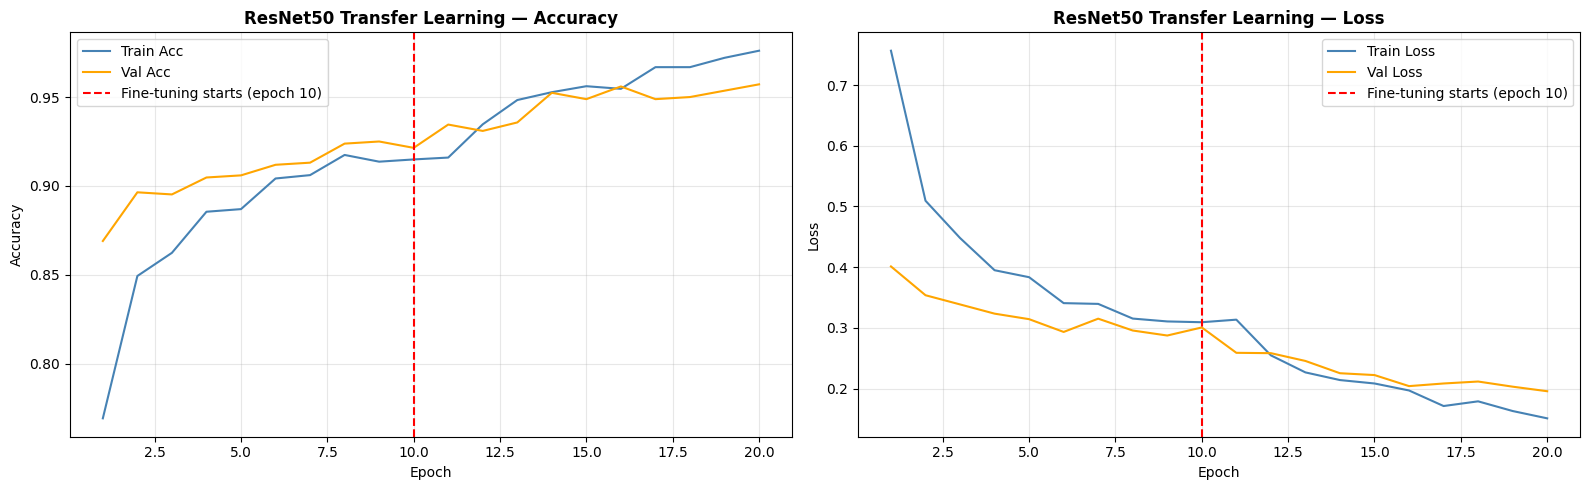

  [✓] Saved: training_curves.png
  Phase 1 (Feature Extraction) : 10 epochs
  Phase 2 (Fine-Tuning)        : 10 epochs
  Best val accuracy overall    : 0.9571 (epoch 20)


In [12]:
# Cell 9: Training History Plots (both phases)

# Guard: if history_ft is missing (kernel was reset), re-run fine-tuning cell first.
if 'history_ft' not in dir() or history_ft is None:
    raise RuntimeError(
        "history_ft is not defined. Please run Cell 8 (Fine-Tuning) before this cell."
    )

def plot_history(hist1, hist2, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Combine both phase histories
    acc      = hist1.history['accuracy']     + hist2.history['accuracy']
    val_acc  = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss     = hist1.history['loss']         + hist2.history['loss']
    val_loss = hist1.history['val_loss']     + hist2.history['val_loss']

    ep1          = len(hist1.history['accuracy'])   # epoch where fine-tuning starts
    epochs_total = range(1, len(acc) + 1)

    # Accuracy
    axes[0].plot(epochs_total, acc,     label='Train Acc', color='steelblue')
    axes[0].plot(epochs_total, val_acc, label='Val Acc',   color='orange')
    axes[0].axvline(ep1, color='red', linestyle='--', label=f'Fine-tuning starts (epoch {ep1})')
    axes[0].set_title(f'{title_prefix} — Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(epochs_total, loss,     label='Train Loss', color='steelblue')
    axes[1].plot(epochs_total, val_loss, label='Val Loss',   color='orange')
    axes[1].axvline(ep1, color='red', linestyle='--', label=f'Fine-tuning starts (epoch {ep1})')
    axes[1].set_title(f'{title_prefix} — Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  [✓] Saved: training_curves.png')
    print(f'  Phase 1 (Feature Extraction) : {ep1} epochs')
    print(f'  Phase 2 (Fine-Tuning)        : {len(acc) - ep1} epochs')
    print(f'  Best val accuracy overall    : {max(val_acc):.4f} (epoch {val_acc.index(max(val_acc)) + 1})')

plot_history(history_fe, history_ft, title_prefix="ResNet50 Transfer Learning")


### Output --

In this visualization, I can observe the combined training history for both phases. The first plot shows **training accuracy** and **validation accuracy**, while the second plot shows **training loss** and **validation loss**. A vertical marker separates **Phase 1 feature extraction** from **Phase 2 fine tuning**.

The printed output confirms that phase 1 ran for **10 epochs**, phase 2 also ran for **10 epochs**, and the best validation accuracy overall is **0.9571 at epoch 20**. This means the model achieved its strongest validation performance at the end of fine tuning. The accuracy curve helps me see the improvement after the pretrained layers were partially unfrozen, while the loss curve helps me check whether the model continues learning without severe overfitting.

I conclude that the two stage training strategy worked well. The graph supports the numerical result by showing that fine tuning improved validation performance beyond the feature extraction stage.

### Below

In the next cell, I evaluate the best saved fine tuned model on the unseen test set. The code loads **best_ft_model.keras**, predicts labels for all test images, calculates main metrics, and prints a detailed classification report.

This cell is one of the most important parts of the notebook because it measures final performance on data that was not used for training or validation. The results include accuracy, weighted precision, weighted recall, weighted F1 score, and weighted one versus rest ROC AUC.

In [13]:
# Cell 10: Model Evaluation — Test Set Metrics
print("=" * 50)
print("EVALUATION ON TEST SET")
print("=" * 50)

# Load best model
model = keras.models.load_model('best_ft_model.keras')

# Get predictions
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_prob, axis=1)
y_true       = test_gen.classes

# Core metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

# AUC (multi-class One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
auc_score  = roc_auc_score(y_true_bin, y_pred_prob, multi_class='ovr', average='weighted')

print(f"\n{'Metric':<25} {'Score':>10}")
print("-" * 37)
print(f"{'Accuracy':<25} {acc:>10.4f}")
print(f"{'Precision (weighted)':<25} {prec:>10.4f}")
print(f"{'Recall (weighted)':<25} {rec:>10.4f}")
print(f"{'F1-Score (weighted)':<25} {f1:>10.4f}")
print(f"{'ROC-AUC (weighted OvR)':<25} {auc_score:>10.4f}")
print(f"\n{'Feature Extraction Time':<25} {fe_training_time/60:>9.2f}m")
print(f"{'Fine-Tuning Time':<25} {ft_training_time/60:>9.2f}m")
print(f"{'Total Training Time':<25} {(fe_training_time+ft_training_time)/60:>9.2f}m")

# Full per-class report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

EVALUATION ON TEST SET
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 237ms/step

Metric                         Score
-------------------------------------
Accuracy                      0.9200
Precision (weighted)          0.9226
Recall (weighted)             0.9200
F1-Score (weighted)           0.9181
ROC-AUC (weighted OvR)        0.9863

Feature Extraction Time       12.60m
Fine-Tuning Time              12.31m
Total Training Time           24.90m

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.78      0.86       400
  meningioma       0.85      0.91      0.88       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.94      1.00      0.97       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



### Output --

In this output, I can observe the final evaluation of the fine tuned ResNet50 model on the test set. The model achieves **0.9200 accuracy**, **0.9226 weighted precision**, **0.9200 weighted recall**, **0.9181 weighted F1 score**, and **0.9863 weighted ROC AUC**. The total training time is **24.90 minutes**, split into **12.60 minutes** for feature extraction and **12.31 minutes** for fine tuning.

The detailed classification report shows that **notumor** and **pituitary** perform strongest, both reaching **1.00 recall** and **0.97 F1 score**. **Glioma** has high precision **0.96** but lower recall **0.78**, meaning some glioma images are missed or confused with other classes. **Meningioma** achieves precision **0.85**, recall **0.91**, and F1 score **0.88**.

I conclude that transfer learning performs very strongly overall. However, the lower glioma recall shows that even a strong ResNet50 model still finds some tumor categories more difficult than others.

### Below

In the next cell, I create confusion matrices from the test predictions. The first confusion matrix shows raw prediction counts, and the second shows normalized proportions.

This visualization helps me understand where the model is correct and where it makes mistakes. In a four class MRI classification task, it is important to know whether errors happen between tumor classes or between tumor and notumor categories.

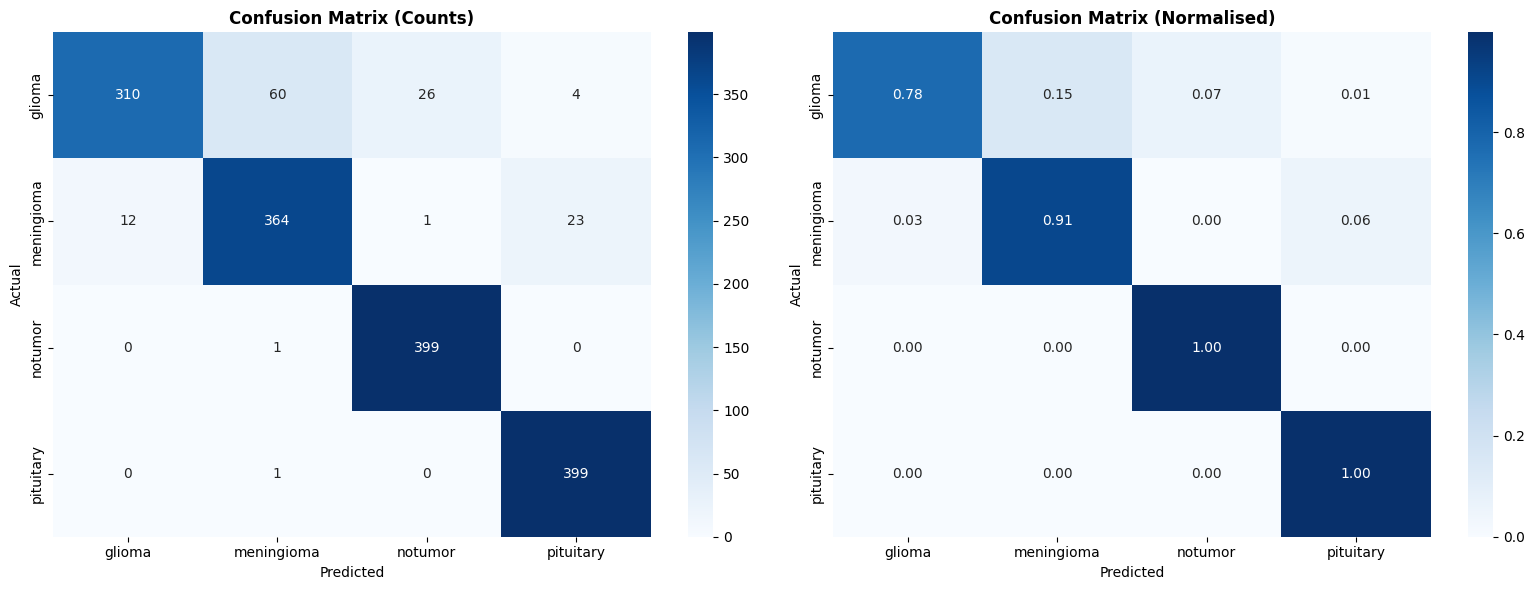

In [14]:
# Cell 11: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

### Output --

In this visualization, I can observe two confusion matrices for the test predictions. The left heatmap shows the raw number of predictions, while the right heatmap shows normalized values for each true class. The x axis represents predicted labels and the y axis represents true labels.

The diagonal cells represent correct classifications, so stronger diagonal values indicate better performance. Off diagonal cells show misclassifications, such as one tumor type being predicted as another. The normalized matrix is especially useful because it shows the proportion of each class predicted correctly or incorrectly, making class specific performance easier to compare.

I conclude that the confusion matrix helps explain the classification report visually. It shows where the model is strongest and where errors occur, especially for classes such as glioma where recall was lower than the other categories.

### Below

In the next cell, I plot ROC curves for each class using a one versus rest approach. Each class is compared against all other classes, and the curve shows the relationship between false positive rate and true positive rate.

This cell helps me evaluate the model beyond simple accuracy. ROC curves show how well the model separates each class across different decision thresholds. A curve close to the top left corner indicates stronger class separation.

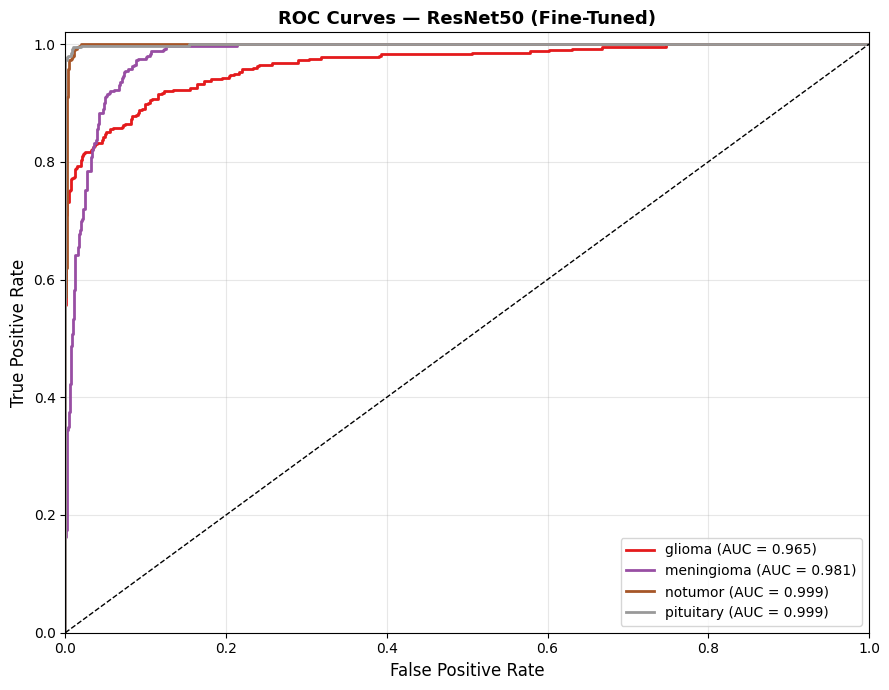

In [15]:
# Cell 12: ROC Curves per Class
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — ResNet50 (Fine-Tuned)', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

### Output --

In this visualization, I can observe ROC curves for each class using a one versus rest approach. The x axis represents **False Positive Rate**, and the y axis represents **True Positive Rate**. Each colored curve represents one class, and the dashed diagonal line represents random guessing.

The curves staying close to the top left corner indicate strong separation between each class and the remaining classes. This matches the high weighted ROC AUC value of **0.9863** from the test evaluation. A high ROC curve suggests that the model ranks correct class probabilities well, even when the decision threshold changes.

I conclude that the ResNet50 model has strong class separation ability. This is important because ROC AUC confirms model quality from a probability ranking perspective, not only from final predicted labels.

### Below

In the next cell, I convert the classification report into a per class bar chart. The chart compares **precision**, **recall**, and **F1 score** for glioma, meningioma, notumor, and pituitary.

This visualization makes the evaluation easier to interpret than a text report alone. It helps me identify which classes the model handles well and which classes still have weaker performance, especially when precision and recall differ.

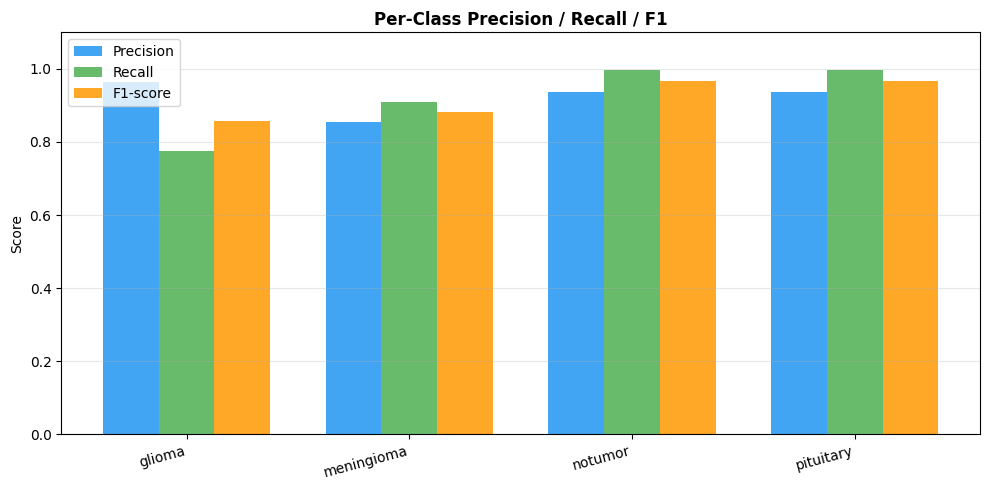

In [16]:
# Cell 13: Per-Class Metrics Visualisation
report = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES, output_dict=True
)
report_df = pd.DataFrame(report).T.iloc[:NUM_CLASSES][['precision','recall','f1-score']]

fig, ax = plt.subplots(figsize=(10, 5))
x   = np.arange(len(CLASS_NAMES))
w   = 0.25
colors_bar = ['#2196F3', '#4CAF50', '#FF9800']

for i, (col, color) in enumerate(zip(report_df.columns, colors_bar)):
    ax.bar(x + i*w, report_df[col], w, label=col.capitalize(), color=color, alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150)
plt.show()

### Output --

In this bar chart, I can observe the per class comparison of **precision**, **recall**, and **F1 score**. Each class has three bars, allowing me to compare the model performance for glioma, meningioma, notumor, and pituitary.

The chart visually confirms the pattern from the classification report. **Notumor** and **pituitary** have the strongest and most balanced scores, while **glioma** shows lower recall compared with its precision. This means that when the model predicts glioma it is usually correct, but it does not catch every real glioma example. Meningioma performs reasonably well but is still weaker than notumor and pituitary.

I conclude that the model is strong overall, but class level evaluation is necessary. The bar chart makes it easier to identify which categories still need improvement, especially glioma recall.

### Below

In the next cell, I display a set of test images with the predicted class, true class, and confidence score. The code reverses the ResNet50 preprocessing for visualization so the MRI images can be viewed clearly.

This step gives a qualitative check of model performance. Instead of only relying on metrics, I can inspect individual predictions and see whether the model is confident, whether predictions look reasonable, and whether any visible mistakes appear in the sample.

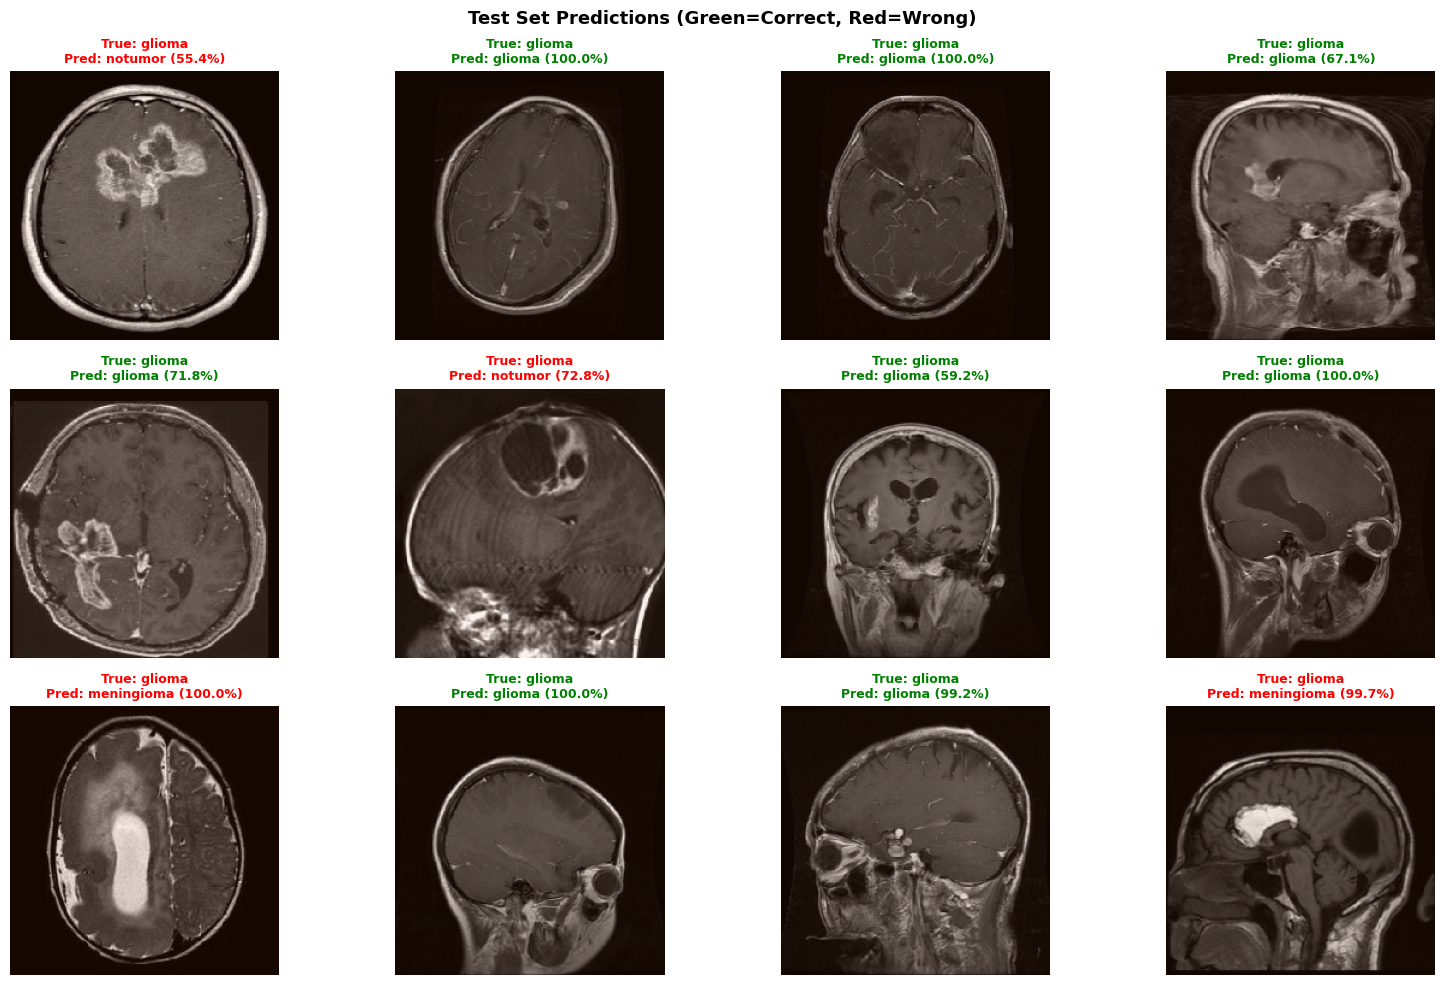

In [17]:
# Cell 14: Visual Predictions on Test Samples
test_gen.reset()
images, labels = next(test_gen)
preds = model.predict(images, verbose=0)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i in range(min(12, len(images))):
    # Reverse ResNet preprocessing for display
    display_img = images[i].copy()
    display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min())
    
    true_label = CLASS_NAMES[np.argmax(labels[i])]
    pred_label = CLASS_NAMES[np.argmax(preds[i])]
    conf       = np.max(preds[i]) * 100
    
    axes[i].imshow(display_img)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({conf:.1f}%)",
        color=color, fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle("Test Set Predictions (Green=Correct, Red=Wrong)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("prediction_samples.png", dpi=150)
plt.show()

### Output --

In this visualization, I can observe twelve test MRI images with their predicted class, true class, and confidence score. The title color indicates whether the prediction is correct or incorrect, and the confidence value shows how strongly the model believes its prediction.

This output is useful because it gives a human readable view of model behavior. A correct prediction with high confidence suggests that the model has learned clear visual evidence for that class. An incorrect prediction with high confidence would be more concerning because it means the model is strongly wrong. This type of inspection helps connect numerical metrics to real image examples.

I conclude that visual prediction checks are important for a medical image classification notebook. They make the evaluation more understandable and help identify whether mistakes occur on visually difficult or ambiguous MRI scans.

### Below

In the next cell, I print the final transfer learning results summary. The summary collects the model name, input size, number of classes, learning rates, test metrics, and training times in one aligned block.

This cell is useful because it gives a compact overview of the whole ResNet50 experiment. It is especially helpful for the final report because the main performance values can be read directly without going back through all earlier training and evaluation cells.

In [18]:
# Cell 15: Final Summary Table

print("       TRANSFER LEARNING RESULTS SUMMARY — ResNet50")


summary = {
    "Model"                  : "ResNet50 (ImageNet → Brain Tumor MRI)",
    "Input Size"             : f"{IMG_SIZE[0]}×{IMG_SIZE[1]}",
    "Num Classes"            : NUM_CLASSES,
    "Feature Extraction LR"  : LR_FE,
    "Fine-Tuning LR"         : LR_FT,
    "Test Accuracy"          : f"{acc:.4f}",
    "Weighted Precision"     : f"{prec:.4f}",
    "Weighted Recall"        : f"{rec:.4f}",
    "Weighted F1-Score"      : f"{f1:.4f}",
    "Weighted ROC-AUC"       : f"{auc_score:.4f}",
    "FE Training Time"       : f"{fe_training_time/60:.2f} min",
    "Fine-Tuning Time"       : f"{ft_training_time/60:.2f} min",
    "Total Training Time"    : f"{(fe_training_time+ft_training_time)/60:.2f} min",
}

for k, v in summary.items():
    print(f"  {k:<30} {str(v):>20}")



       TRANSFER LEARNING RESULTS SUMMARY — ResNet50
  Model                          ResNet50 (ImageNet → Brain Tumor MRI)
  Input Size                                  224×224
  Num Classes                                       4
  Feature Extraction LR                         0.001
  Fine-Tuning LR                                1e-05
  Test Accuracy                                0.9200
  Weighted Precision                           0.9226
  Weighted Recall                              0.9200
  Weighted F1-Score                            0.9181
  Weighted ROC-AUC                             0.9863
  FE Training Time                          12.60 min
  Fine-Tuning Time                          12.31 min
  Total Training Time                       24.90 min


### Output --

In this output, I can observe the final transfer learning summary for the ResNet50 model. The model is listed as **ResNet50 ImageNet to Brain Tumor MRI**, with input size **224 by 224**, **4 classes**, feature extraction learning rate **0.001**, and fine tuning learning rate **0.00001**.

The summary reports the main test results: **0.9200 test accuracy**, **0.9226 weighted precision**, **0.9200 weighted recall**, **0.9181 weighted F1 score**, and **0.9863 weighted ROC AUC**. It also reports **12.60 minutes** for feature extraction, **12.31 minutes** for fine tuning, and **24.90 minutes** total training time.

I conclude that this final summary clearly presents the outcome of the ResNet50 experiment. It is suitable for use in the report because it combines performance and computational cost in one place.

### Below

In the next cell, I compare the transfer learning model with the baseline CNN and the deeper CNN trained from scratch. The code uses the test metrics from all three notebooks and displays them in a printed comparison table and a grouped bar chart.

This comparison is important because it answers the main experimental question: whether transfer learning with ResNet50 improves performance compared with custom CNN models trained from scratch. The metrics compared are accuracy, weighted precision, weighted recall, and weighted F1 score.

  CROSS-MODEL COMPARISON: All Three Architectures
  Metric                     Baseline CNN       Deeper CNN    ResNet50 (TL)
------------------------------------------------------------------------
  Accuracy                         0.8013           0.8725           0.9200
  Weighted Precision               0.8126           0.8808           0.9226
  Weighted Recall                  0.8013           0.8725           0.9200
  Weighted F1                      0.7897           0.8697           0.9181


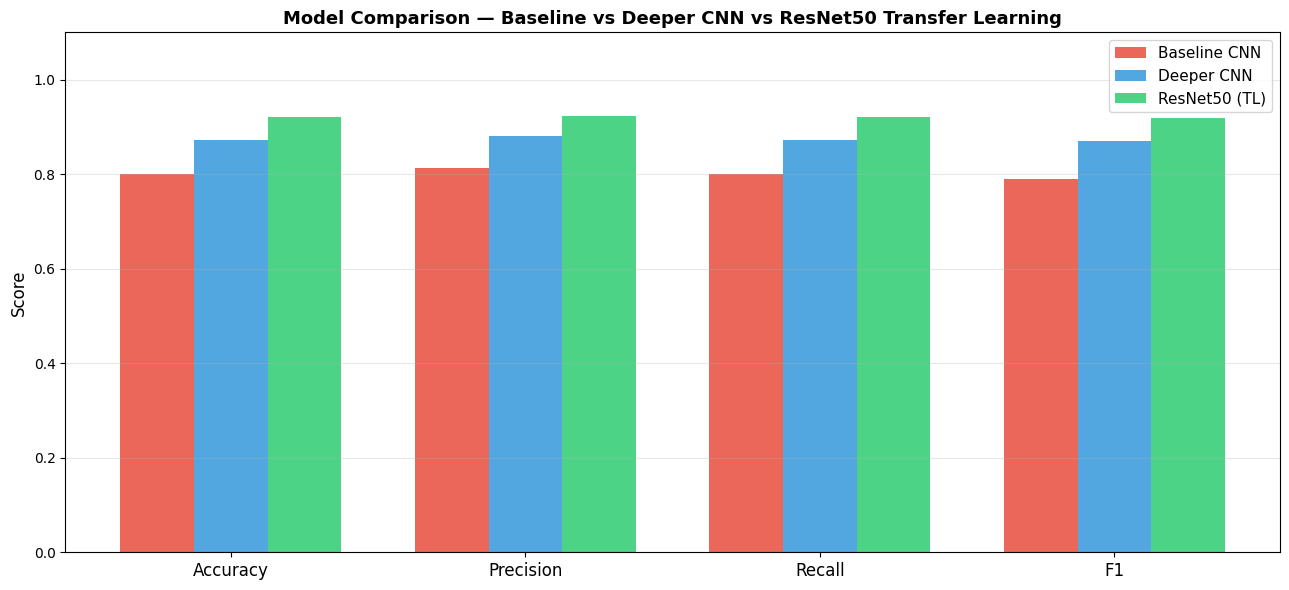

  [✓] Saved: model_comparison_all.png


In [19]:
# ── Cross-model comparison: ResNet50 vs Baseline vs Deeper CNN ──
import numpy as np
import matplotlib.pyplot as plt

BASELINE_ACC   = 0.8013
BASELINE_PREC  = 0.8126
BASELINE_REC   = 0.8013
BASELINE_F1    = 0.7897

DEEPER_ACC     = 0.8725
DEEPER_PREC    = 0.8808
DEEPER_REC     = 0.8725
DEEPER_F1      = 0.8697

# ResNet50 values from this notebook (computed in Cell 10)
RESNET_ACC     = acc
RESNET_PREC    = prec
RESNET_REC     = rec
RESNET_F1      = f1

# ── Printed comparison table ──
print('='*72)
print('  CROSS-MODEL COMPARISON: All Three Architectures')
print('='*72)
print(f"  {'Metric':<22} {'Baseline CNN':>16} {'Deeper CNN':>16} {'ResNet50 (TL)':>16}")
print('-'*72)
rows = [
    ('Accuracy',          BASELINE_ACC,  DEEPER_ACC,  RESNET_ACC),
    ('Weighted Precision',BASELINE_PREC, DEEPER_PREC, RESNET_PREC),
    ('Weighted Recall',   BASELINE_REC,  DEEPER_REC,  RESNET_REC),
    ('Weighted F1',       BASELINE_F1,   DEEPER_F1,   RESNET_F1),
]
for label, b, d, r in rows:
    print(f"  {label:<22} {b:>16.4f} {d:>16.4f} {r:>16.4f}")
print('='*72)

# ── Bar chart comparison ──
model_names = ['Baseline CNN', 'Deeper CNN', 'ResNet50 (TL)']
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1']
values      = [
    [BASELINE_ACC,  DEEPER_ACC,  RESNET_ACC],
    [BASELINE_PREC, DEEPER_PREC, RESNET_PREC],
    [BASELINE_REC,  DEEPER_REC,  RESNET_REC],
    [BASELINE_F1,   DEEPER_F1,   RESNET_F1],
]

x      = np.arange(len(metrics))
w      = 0.25
colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [v[i] for v in values]
    ax.bar(x + i*w, vals, w, label=name, color=color, alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Baseline vs Deeper CNN vs ResNet50 Transfer Learning',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('  [✓] Saved: model_comparison_all.png')


### Output --

In this output, I can observe the final cross model comparison between **Baseline CNN**, **Deeper CNN**, and **ResNet50 transfer learning**. The printed table shows that the baseline CNN achieves **0.8013 accuracy** and **0.7897 weighted F1**, the deeper CNN achieves **0.8725 accuracy** and **0.8697 weighted F1**, and ResNet50 achieves **0.9200 accuracy** and **0.9181 weighted F1**.

The grouped bar chart visually confirms that ResNet50 performs best across all four metrics: accuracy, weighted precision, weighted recall, and weighted F1 score. The deeper CNN improves over the baseline model, but transfer learning gives the strongest performance overall. This shows that pretrained ImageNet features are useful even though MRI images are different from natural images.

I conclude that transfer learning is the best architecture choice in this experiment. ResNet50 provides the highest predictive performance, while the scratch trained CNN models act as useful baselines for showing the improvement gained from pretrained feature extraction and fine tuning.